In [ ]:
import yaml
import torch
import numpy as np
from box import Box
from torch import optim
from pathlib import Path
from utils import plotPCbatch
from torch.autograd import grad
from matplotlib import pyplot as plt
from dataloaders import GetDataLoaders
from models import PointCloudAE, Generator, Discriminator

In [ ]:
with open("config.yaml", "r") as file:
    args = yaml.safe_load(file)
args = Box(args)
print(args)

args.data_dir = Path.home()/args.data_dir
args.model_dir = Path.home()/args.model_dir

{'device': 'cuda', 'batch_size': 32, 'data_dir': 'onedrive_local/research/material_liu/data', 'model_dir': 'onedrive_local/research/material_liu/model', 'load_ae': False, 'dataset': 'chair_set.npy', 'output_folder': 'output/', 'save_results': True, 'latent_size': 128, 'ae_epoch': 1001, 'gan_epoch': 100, 'gan_batch': 64, 'lambda_gp': 10}


In [ ]:
data_file = args.data_dir/args.dataset
pc_array = np.load(data_file)
print(f"data shape: {pc_array.shape}.")

point_size = pc_array.shape[1]
print(f"number of points in one 3D cloud: {point_size}.")
loader, _ = GetDataLoaders(npArray=pc_array, 
                           batch_size=args.batch_size, 
                           train_set_percentage=1.0)

data shape: (3746, 1024, 3).
number of points in one 3D cloud: 1024.


In [ ]:
ae = PointCloudAE(point_size, args.latent_size).to(args.device)
checkpoint = torch.load(args.model_dir/"ae.pt", weights_only=True)
ae.load_state_dict(checkpoint)
ae.eval()
print("Successfully load ae!")

Successfully load ae!


/home/yalin/anaconda3/envs/py3d/lib/python3.9/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


torch.Size([32, 1024, 3])


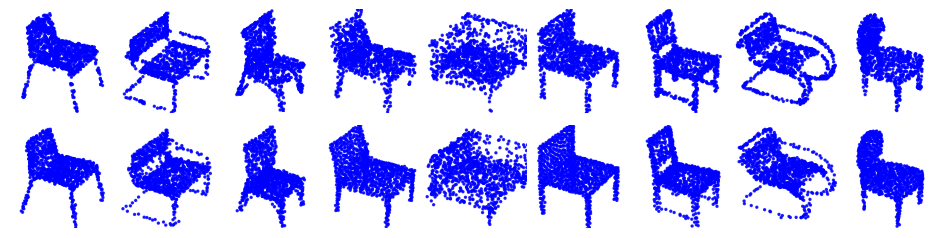

In [ ]:
with torch.no_grad():
    x = next(iter(loader))
    x = x.to(args.device)
    x_hat = ae(x.permute(0,2,1))
print(x_hat.shape)
plotPCbatch(x.cpu(), x_hat.cpu())

In [ ]:
def generate_embedding(generator, batch_size, device, latent_dim=128):
    noise = torch.randn(batch_size, latent_dim, device=device)
    return generator(noise)

@torch.no_grad()
def generate_sample(generator, ae, batch_size, device, latent_dim=128):
    z_gen = generate_embedding(generator, batch_size, device, latent_dim)
    x = ae.decoder(z_gen).cpu()
    return x

In [ ]:
def compute_gradient_penalty(discriminator, real_samples, fake_samples, device):

    # Compute gradient penalty for WGAN-GP, works with arbitrary input dimensions.
    batch_size = real_samples.size(0)
    alpha = torch.rand(batch_size, *[1] * (real_samples.dim() - 1), device=device)

    interpolates = alpha * real_samples + (1 - alpha) * fake_samples
    interpolates.requires_grad_(True)

    d_interpolates = discriminator(interpolates)
    fake = torch.ones_like(d_interpolates, device=device)

    gradients = grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    # Flatten each sample's gradients: (B, D1, D2, ...) -> (B, -1)
    gradients = gradients.view(batch_size, -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()

    return gradient_penalty


# training loop
def training_gan(epochs, latent_size, gan_batch, lambda_gp, device):

    print("start to train gan")
    
    losses = Box(g=[],d=[])
    for epoch in range(epochs):
        dis_batch_losses = []
        gen_batch_losses = []
        for i, x in enumerate(loader):
            x = x.to(device)
            with torch.no_grad():
                true_embedding = ae.encoder(x.permute(0,2,1))
            z = torch.randn(gan_batch, latent_size, device=device)
            # fake_embedding = gan_g(z).detach()
            fake_embedding = gan_g(z)

            # train discriminator
            d_real = gan_d(true_embedding)
            d_fake = gan_d(fake_embedding.detach())
            gp = compute_gradient_penalty(gan_d, true_embedding, fake_embedding.detach(), device)
            loss_d = -torch.mean(d_real) + torch.mean(d_fake) + lambda_gp * gp
            opt_d.zero_grad()
            loss_d.backward()
            opt_d.step()
            dis_batch_losses.append(loss_d.item())

            # update one time per five times to update discriminator
            if i % 5 == 0:
                # z = torch.randn(gan_batch, latent_size, device=device)
                # fake_embedding = gan_g(z)
                loss_g = -torch.mean(gan_d(fake_embedding))
                opt_g.zero_grad()
                loss_g.backward()
                opt_g.step()
                gen_batch_losses.append(loss_g.item())
        
        dis_avg_loss = np.mean(dis_batch_losses)
        gen_avg_loss = np.mean(gen_batch_losses)
        print(f"epoch {epoch+1}/{epochs} | loss_d: {dis_avg_loss:.4f} | loss_g: {gen_avg_loss:.4f}")

        losses.d.append(dis_avg_loss)
        losses.g.append(gen_avg_loss)

    return losses

start to train gan
epoch 1/100 | loss_d: 4.4133 | loss_g: -0.1734
epoch 2/100 | loss_d: -1.5932 | loss_g: -0.8006
epoch 3/100 | loss_d: -2.9202 | loss_g: -0.5346
epoch 4/100 | loss_d: -2.7610 | loss_g: -0.2142
epoch 5/100 | loss_d: -1.7961 | loss_g: -0.6815
epoch 6/100 | loss_d: -0.8527 | loss_g: -0.4285
epoch 7/100 | loss_d: -0.2945 | loss_g: -0.2571
epoch 8/100 | loss_d: -0.3869 | loss_g: 0.0172
epoch 9/100 | loss_d: -0.7092 | loss_g: 0.4557
epoch 10/100 | loss_d: -0.6318 | loss_g: 0.1719
epoch 11/100 | loss_d: -0.6913 | loss_g: 0.1584
epoch 12/100 | loss_d: -0.6821 | loss_g: 0.1359
epoch 13/100 | loss_d: -0.7077 | loss_g: 0.0528
epoch 14/100 | loss_d: -0.7122 | loss_g: 0.1310
epoch 15/100 | loss_d: -0.7186 | loss_g: 0.1001
epoch 16/100 | loss_d: -0.7016 | loss_g: 0.0442
epoch 17/100 | loss_d: -0.7058 | loss_g: 0.1951
epoch 18/100 | loss_d: -0.7088 | loss_g: 0.0778
epoch 19/100 | loss_d: -0.6946 | loss_g: 0.0673
epoch 20/100 | loss_d: -0.6710 | loss_g: 0.0206
epoch 21/100 | loss_d: -

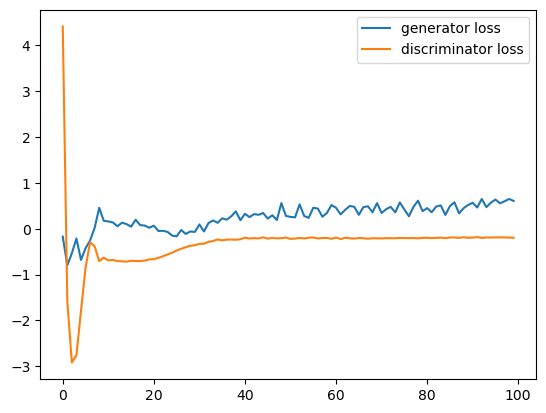

In [ ]:
if __name__ == "__main__":


    loader, _ = GetDataLoaders(npArray=pc_array, 
                           batch_size=args.gan_batch, 
                           train_set_percentage=1.0)
    
    gan_g = Generator().to(args.device)
    opt_g = optim.AdamW(gan_g.parameters(), lr=1e-4, betas=(0.5, 0.9))
    gan_d = Discriminator().to(args.device)
    opt_d = optim.AdamW(gan_d.parameters(), lr=1e-4, betas=(0.5, 0.9))

    losses = training_gan(args.gan_epoch, args.latent_size, args.gan_batch, args.lambda_gp, args.device)

    # display training loss
    plt.plot(losses.g, label="generator loss")
    plt.plot(losses.d, label="discriminator loss")
    plt.legend()
    plt.show()
    plt.close()

    # save model
    torch.save(gan_g.state_dict(), args.model_dir/"wgan_g.pt")
    torch.save(gan_d.state_dict(), args.model_dir/"wgan_d.pt")